In [ ]:
import pickle
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load data splits
with open('../data/processed/data_splits.pkl', 'rb') as f:
    data = pickle.load(f)

X_train = data['X_train']
X_val = data['X_val']
X_test = data['X_test']
y_train = data['y_train']
y_val = data['y_val']
y_test = data['y_test']
le = data['label_encoder']

print(f"Train: {X_train.shape}")
print(f"Val  : {X_val.shape}")
print(f"Test : {X_test.shape}")
print(f"Classes: {le.classes_}")

Train: (79845, 50000)
Val  : (17110, 50000)
Test : (17110, 50000)
Classes: ['Critical' 'Low' 'Medium']


In [ ]:
# Train Logistic Regression
lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    C=1.0,
    solver='lbfgs',
    random_state=42
)

lr_model.fit(X_train, y_train)

# Evaluasi di validation set
y_val_pred = lr_model.predict(X_val)
val_acc = accuracy_score(y_val, y_val_pred)
print(f"\nValidation Accuracy: {val_acc*100:.2f}%")


Validation Accuracy: 80.20%


In [ ]:
# Evaluasi Detail di Test Set
y_test_pred = lr_model.predict(X_test)

print("Evaluasi Logistic Regression (Test Set)")
print(f"Accuracy: {accuracy_score(y_test, y_test_pred)*100:.2f}%")
print(f"\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=le.classes_))

Evaluasi Logistic Regression (Test Set)
Accuracy: 80.36%

Classification Report:
              precision    recall  f1-score   support

    Critical       0.73      0.80      0.76      1119
         Low       0.75      0.83      0.79      6779
      Medium       0.86      0.78      0.82      9212

    accuracy                           0.80     17110
   macro avg       0.78      0.80      0.79     17110
weighted avg       0.81      0.80      0.80     17110



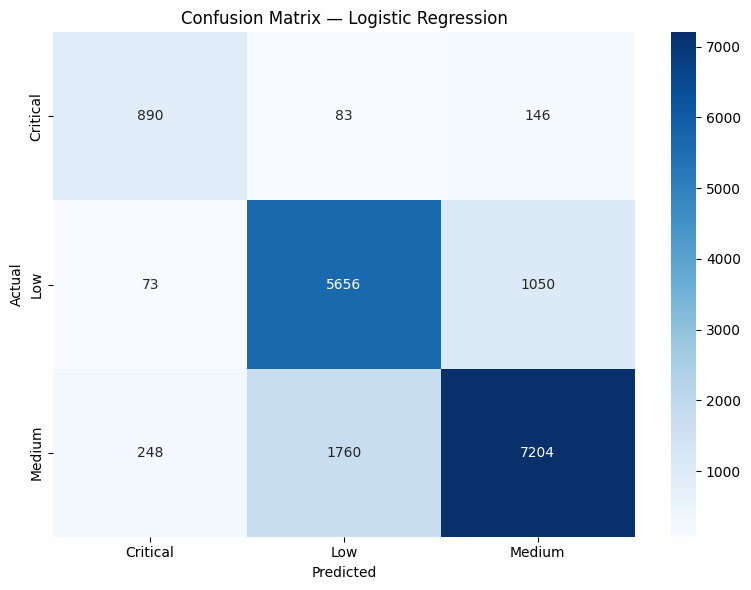

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Confusion Matrix — Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [ ]:
# Simpan Model
with open('../data/processed/LR_model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)